# Notebook 3 — Transfer Learning Classification

Fine-tune **EfficientNet-B0** (pretrained on ImageNet) to classify 15 PlantVillage categories.

**Training strategy:**
- Phase 1 (epochs 1–3): freeze backbone, train head only
- Phase 2 (epochs 4–7): unfreeze all layers, fine-tune at 10× lower LR
- `WeightedRandomSampler` + class-weighted loss for the 21:1 class imbalance

**Expected time (CPU-only):** ~2.5–5 h for 7 epochs over 14,337 images.
For a quick smoke-test, set `QUICK_RUN = True` below to subsample 4,000 images and run 3 epochs.

In [3]:
print('oi')

oi


In [4]:
import os
import json
import pathlib
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder
import timm
from sklearn.model_selection import train_test_split

# ── Configuration ────────────────────────────────────────────────────────────
DATASET_ROOT   = pathlib.Path(
    r"C:\Users\Admin\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\PlantVillage"
)
CHECKPOINT_DIR = pathlib.Path("../models")
CHECKPOINT_DIR.mkdir(exist_ok=True)
DOCS_DIR       = pathlib.Path("../docs")
DOCS_DIR.mkdir(exist_ok=True)

QUICK_RUN     = True   # Set True for a fast 3-epoch smoke-test on 4,000 images
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 3 if QUICK_RUN else 7
FREEZE_EPOCHS = 1 if QUICK_RUN else 3   # backbone frozen for first N epochs
LR            = 1e-3
SEED          = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Quick run: {QUICK_RUN} | Epochs: {NUM_EPOCHS}")

Device: cpu
Quick run: True | Epochs: 3


## 1. Data Transforms

In [5]:
# Normalization constants computed in notebook2_eda.ipynb from the PlantVillage dataset.
# Update these if notebook2 printed different values for your system.
MEAN = [0.4695, 0.4813, 0.4236]
STD  = [0.1984, 0.1740, 0.2114]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print("Transforms defined.")

Transforms defined.


## 2. Dataset Split & Weighted Sampler

In [6]:
# Build the full dataset with train transforms (val/test will use a separate instance)
full_train_ds = ImageFolder(root=str(DATASET_ROOT), transform=train_transforms)
full_val_ds   = ImageFolder(root=str(DATASET_ROOT), transform=val_transforms)

class_names = full_train_ds.classes
NUM_CLASSES  = len(class_names)
print(f"Classes ({NUM_CLASSES}): {class_names}")

all_indices = list(range(len(full_train_ds)))
all_labels  = full_train_ds.targets

# Optional: subsample for quick run
if QUICK_RUN:
    subsample_idx, _, subsample_lbl, _ = train_test_split(
        all_indices, all_labels, train_size=4000,
        stratify=all_labels, random_state=SEED
    )
    all_indices = subsample_idx
    all_labels  = subsample_lbl
    print(f"Quick run: using {len(all_indices)} images")

# Stratified 70 / 15 / 15 split
train_idx, temp_idx, train_lbl, temp_lbl = train_test_split(
    all_indices, all_labels, test_size=0.30,
    stratify=all_labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=temp_lbl, random_state=SEED
)
print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")

# Save the split indices so notebook4 can reconstruct the exact test set
np.save(CHECKPOINT_DIR / "test_indices.npy", np.array(test_idx))
print("Saved test_indices.npy")

Classes (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Quick run: using 4000 images
Train: 2800  Val: 600  Test: 600
Saved test_indices.npy


In [8]:
# Weighted sampler to counteract the severe class imbalance (up to 21:1 ratio)
class_counts  = np.bincount(train_lbl, minlength=NUM_CLASSES)
class_weights = 1.0 / np.where(class_counts == 0, 1, class_counts)  # avoid div-by-zero

sample_weights = class_weights[train_lbl]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_idx),
    replacement=True,
)

train_set = Subset(full_train_ds, train_idx)
val_set   = Subset(full_val_ds,   val_idx)
test_set  = Subset(full_val_ds,   test_idx)

# num_workers=2 is safe on Windows; pin_memory=False when no GPU
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=2, pin_memory=DEVICE.type == "cuda",
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=DEVICE.type == "cuda",
)
test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=DEVICE.type == "cuda",
)
print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 88


## 3. Model — EfficientNet-B0 via timm

In [9]:
def build_model(num_classes, freeze_backbone=True):
    model = timm.create_model(
        "efficientnet_b0",
        pretrained=True,
        num_classes=num_classes,
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
    return model


model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}  (backbone frozen)")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total params:     4,026,763
Trainable params: 19,215  (backbone frozen)


c:\repo\teste_kaggle\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 4. Loss, Optimizer, and Scheduler

In [10]:
# Class-weighted cross-entropy for additional imbalance correction on the loss side
weights_tensor = torch.tensor(
    class_weights / class_weights.sum() * NUM_CLASSES,
    dtype=torch.float32,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FREEZE_EPOCHS)

print("Criterion, optimizer, and scheduler ready.")

Criterion, optimizer, and scheduler ready.


## 5. Training Loop

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Phase transition: unfreeze backbone after FREEZE_EPOCHS ─────────────
    if epoch == FREEZE_EPOCHS + 1:
        print("\n--- Unfreezing backbone for full fine-tuning ---")
        for param in model.parameters():
            param.requires_grad = True
        trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable params: {trainable_now:,}")
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR / 10, weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - FREEZE_EPOCHS
        )

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(
            {"epoch": epoch, "model_state": model.state_dict(), "class_names": class_names},
            CHECKPOINT_DIR / "best_model.pth",
        )
        marker = " ★ best"
    else:
        marker = ""

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train  loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
        f"Val  loss {vl_loss:.4f}  acc {vl_acc:.3f} | "
        f"{elapsed:.0f}s{marker}"
    )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# Save class names
with open(CHECKPOINT_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("Saved best_model.pth and class_names.json")

Epoch  1/3 | Train  loss 2.2467  acc 0.219 | Val  loss 2.1919  acc 0.272 | 152s ★ best

--- Unfreezing backbone for full fine-tuning ---
Trainable params: 4,026,763
Epoch  2/3 | Train  loss 0.5318  acc 0.709 | Val  loss 0.5242  acc 0.812 | 351s ★ best
Epoch  3/3 | Train  loss 0.2067  acc 0.882 | Val  loss 0.4028  acc 0.853 | 316s ★ best

Best validation accuracy: 0.8533
Saved best_model.pth and class_names.json


## 6. Learning Curves

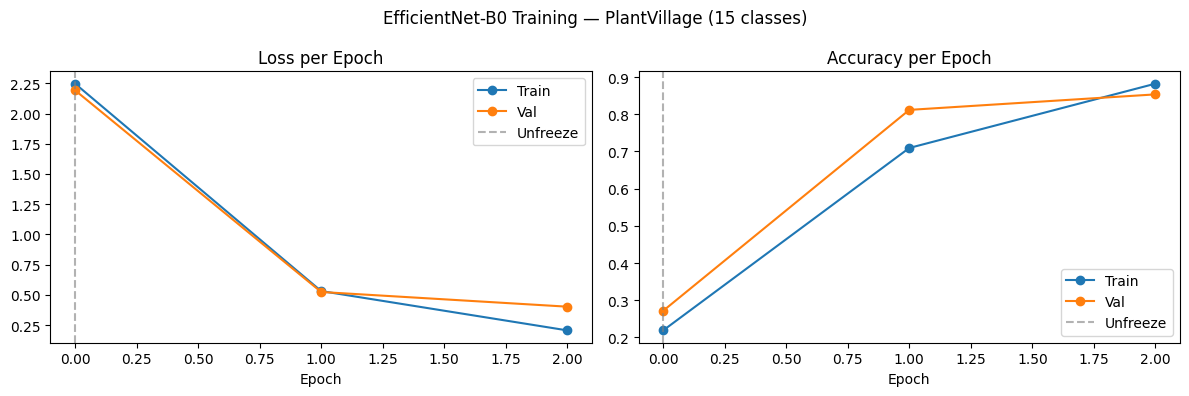

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train", marker="o")
ax1.plot(history["val_loss"],   label="Val",   marker="o")
ax1.axvline(FREEZE_EPOCHS - 1, color="gray", linestyle="--", alpha=0.6, label="Unfreeze")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_acc"], label="Train", marker="o")
ax2.plot(history["val_acc"],   label="Val",   marker="o")
ax2.axvline(FREEZE_EPOCHS - 1, color="gray", linestyle="--", alpha=0.6, label="Unfreeze")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle("EfficientNet-B0 Training — PlantVillage (15 classes)", fontsize=12)
plt.tight_layout()
plt.savefig(DOCS_DIR / "training_curves.png", dpi=150)
plt.show()